In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

import json
import numpy as np
import matplotlib.pyplot as plt

RUNS = [
    ("SlotODE, T = 3, dt =1.0", "slotode_T3_dt1_curve.json"),
    ("SlotODE, T = 3, dt=0.5", "slotode_T3_dt0.5_curve.json"),
    ("Slot Attention, T = 3", "baseline_T3_curve.json"),
]

curves = {}
for name, path in RUNS:
    with open(path) as f:
        d = json.load(f)
    steps = sorted(int(s) for s in d.keys())
    curves[name] = {
        "steps": np.array(steps),
        "train_ari":  np.array([d[str(s)]["train"]["ari_fg"] for s in steps]),
        "val_ari":    np.array([d[str(s)]["val"]["ari_fg"] for s in steps]),
        "train_mse":  np.array([d[str(s)]["train"]["mse"] for s in steps]),
        "val_mse":    np.array([d[str(s)]["val"]["mse"] for s in steps]),
    }
    print(f"{name}: {len(steps)} ckpts, {steps[0]}..{steps[-1]}")

SlotODE, T = 3, dt =1.0: 50 ckpts, 10000..500000
SlotODE, T = 3, dt=0.5: 50 ckpts, 10000..500000
Slot Attention, T = 3: 50 ckpts, 10000..500000


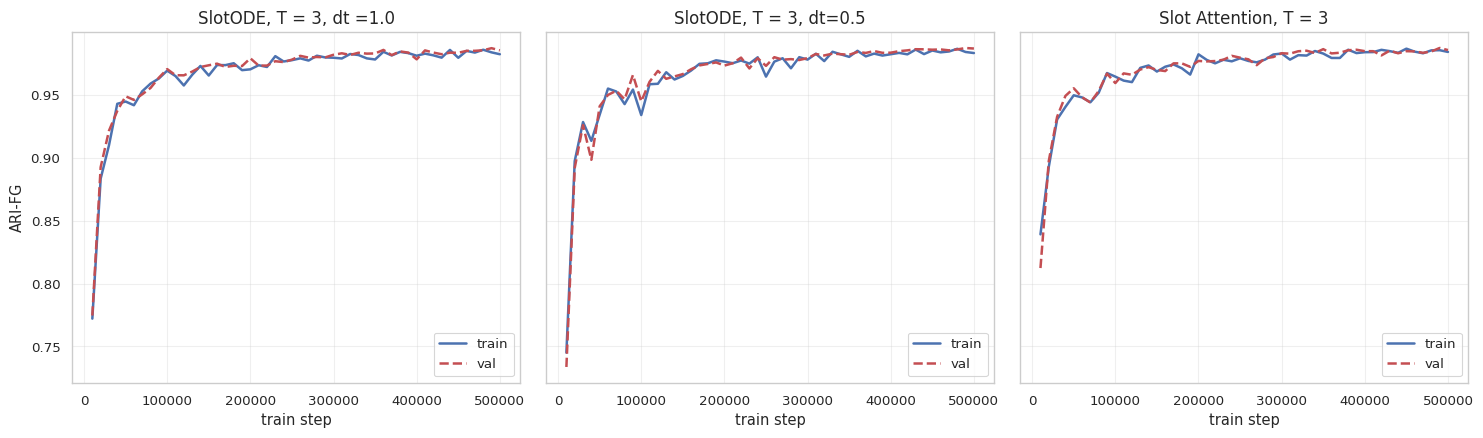

In [17]:
# ARI-FG convergence: 3 subplots, train vs val per model
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, (name, _) in zip(axes, RUNS):
    c = curves[name]
    ax.plot(c["steps"], c["train_ari"], label="train", color="C0", linewidth=1.8)
    ax.plot(c["steps"], c["val_ari"],   label="val",   color="C3", linewidth=1.8, linestyle="--")
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("train step")
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right")
axes[0].set_ylabel("ARI-FG")
plt.tight_layout()
plt.savefig("convergence_ari.png", dpi=150, bbox_inches="tight")
plt.show()

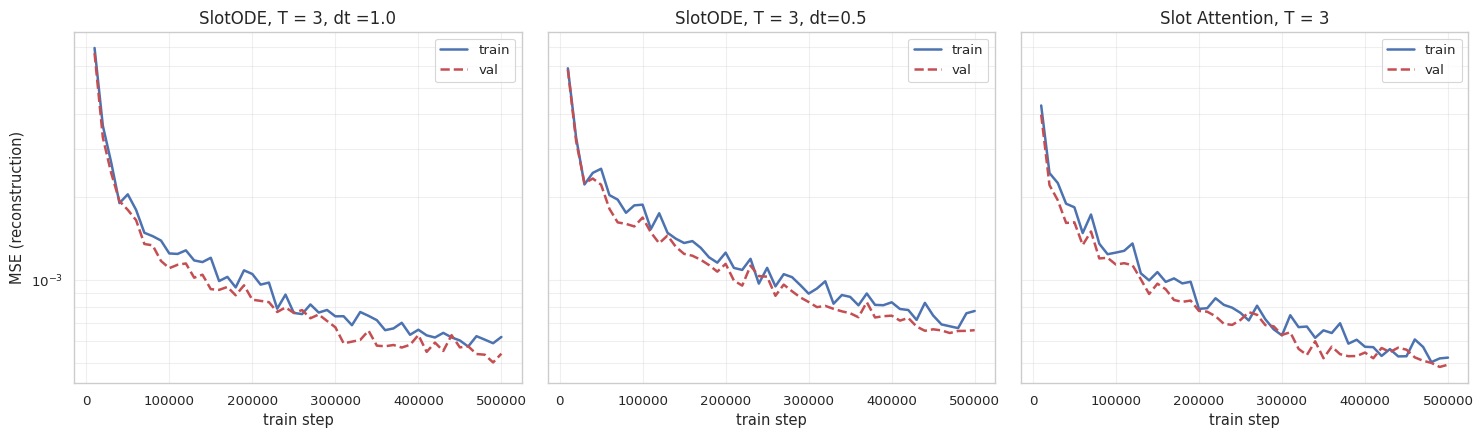

In [21]:
# MSE convergence: 3 subplots, log scale
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, (name, _) in zip(axes, RUNS):
    c = curves[name]
    ax.plot(c["steps"], c["train_mse"], label="train", color="C0", linewidth=1.8)
    ax.plot(c["steps"], c["val_mse"],   label="val",   color="C3", linewidth=1.8, linestyle="--")
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("train step")
    ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="upper right")
axes[0].set_ylabel("MSE (reconstruction)")
plt.tight_layout()
plt.savefig("convergence_mse.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Overlay comparison (bonus): all 3 runs on same axis, val ARI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"SlotODE T3 (dt=1.0)": "C0", "SlotODE T3 (dt=0.5)": "C2", "Baseline SA T3": "C3"}
for name, _ in RUNS:
    c = curves[name]
    ax1.plot(c["steps"], c["val_ari"], label=name, color=colors[name], linewidth=1.8)
    ax2.plot(c["steps"], c["val_mse"], label=name, color=colors[name], linewidth=1.8)
ax1.set_xlabel("training step"); ax1.set_ylabel("val ARI-FG"); ax1.grid(alpha=0.3); ax1.legend()
ax2.set_xlabel("training step"); ax2.set_ylabel("val MSE"); ax2.set_yscale("log"); ax2.grid(alpha=0.3, which="both"); ax2.legend()
fig.suptitle("Validation convergence comparison", fontsize=13)
plt.tight_layout()
plt.show()